In [9]:
##### IMPORTS

import os, re
import numpy as np
import matplotlib.pyplot as plt

In [10]:
### FILES

file1 = r"C:\Users\Alex\Desktop\Picaso\NN_project\compare_cases\Pt790.3769135035916g2056.7149450539773.npy"
file2 = r"C:\Users\Alex\Desktop\Picaso\NN_project\compare_cases\At790.3769135035916g2056.7149450539773.npy"
cloudfile1 = r"C:\Users\Alex\Desktop\Picaso\NN_project\compare_cases\t790.3769135035916g2056.7149450539778f2.0k1e9c12345.npy"
cloudfile2 = r"C:\Users\Alex\Desktop\Picaso\NN_project\compare_cases\t790.3769135035916g2056.7149450539778f1.0k1e9c12345.npy"
cloudfile3 = r"C:\Users\Alex\Desktop\Picaso\NN_project\compare_cases\t790.3769135035916g2056.7149450539778f3.0k1e9c12345.npy"

In [3]:
##### CLOUD FREE CONFIGURATION

def clfree_name(path):
    base = os.path.basename(path)
    m = re.search(r"t(?P<T>[0-9.]+)g(?P<G>[0-9.]+)\.npy$", base)
    if m is None:
        raise ValueError(f"Could not parse T,g from filename: {base}")
    T = float(m.group("T"))
    g = float(m.group("G"))
    return T, g

def clfree_flux(file):
    # Loading in the flux from file
    clfreeFLUX = np.load(file, allow_pickle=True)
    # Creating wavenumber grid
    wnmin, wnmax  = 333.3, 20000.0
    wn            = np.linspace(wnmax, wnmin, clfreeFLUX.size)
    # Convert to micron, should be 0.5 to 30 micron
    wl            = 1e4 / wn
    wlmin, wlmax  = np.min(wl), np.max(wl)
    # Convert FLUX to per micron
    clfreeFLM     = clfreeFLUX * (1e4 / wl**2)
    # Sort
    idx           = np.argsort(wl)
    wl_val        = wl[idx]
    fl_val        = clfreeFLM[idx]
    fl_valog      = clfreeFLUX[idx] # erg cm^-2 s^-1 cm^-1
    return wl_val, fl_valog

In [4]:
##### CLOUD CONFIGURATION

cloud_dict = {'Fe': '1', 'KCl': '2', 'Mg2SiO4': '3', 'MgSiO3': '4', 'Na2S': '5'}

digit_to_species = {v: k for k, v in cloud_dict.items()}


def cloudy_name(path):
    base = os.path.basename(path)
    pat  = r"t(?P<T>[0-9.]+)g(?P<g>[0-9.]+)f(?P<fsed>[0-9.]+)k(?P<kzz>[\deE.+-]+)c(?P<codes>[0-9]+)\.npy$"
    m = re.search(pat, base)
    if m is None:
        raise ValueError(f"Could not parse: {base}")

    T    = float(m.group("T"))
    g = float(m.group("g"))          # cgs, dex
    fsed = float(m.group("fsed"))
    kzz  = m.group("kzz")                  # keep as string like "1e10"
    code_str = m.group("codes")
    clouds_used = [digit_to_species.get(d, f"code{d}") for d in code_str]

    return T, g, fsed, kzz, clouds_used

def cloudy_flux(file):
    cloudyFLUX = np.load(file, allow_pickle=True)
    # Creating wavenumber grid - HALF OF PETER SO FAR, CHANGE WHEN RUNNING 30 MICRON
    wnminc, wnmaxc  = 333.3, 20000.0
    wnc             = np.linspace(wnmaxc, wnminc, cloudyFLUX.size)
    # Convert to micron, should be 0.5 to 30 micron
    wlc             = 1e4 / wnc
    wlminc, wlmaxc  = np.min(wlc), np.max(wlc)
    # Convert FLUX to per micron
    cloudyFLM       = cloudyFLUX * (1e4 / wlc**2)
    # Sort
    idxc            = np.argsort(wlc)
    wlc_val         = wlc[idxc]
    flc_val         = cloudyFLM[idxc]
    flc_valog       = cloudyFLUX[idxc]
    return wlc_val, flc_valog

In [11]:
##### EXECUTE

# Cloud free
wl1, F1 = clfree_flux(file1)
T1, g1  = clfree_name(file1)

wl2, F2 = clfree_flux(file2)
T2, g2  = clfree_name(file2)

# Cloudy
wlc1, Fc1 = cloudy_flux(cloudfile1)
clT1, cg1, fsed1, kzz1, clouds1 = cloudy_name(cloudfile1)

wlc2, Fc2 = cloudy_flux(cloudfile2)
clT2, cg2, fsed2, kzz2, clouds2 = cloudy_name(cloudfile2)

wlc3, Fc3 = cloudy_flux(cloudfile3)
clT3, cg3, fsed3, kzz3, clouds3 = cloudy_name(cloudfile3)

Length: (20472, 20472)
Min/Max F1: 374.6286331926265, 622581528371.7538
Min/Max F2: 379.0845782299495, 729543462169.8365
Mean absolute difference: 5176392971.159507
Mean relative difference: 0.1618831069900991


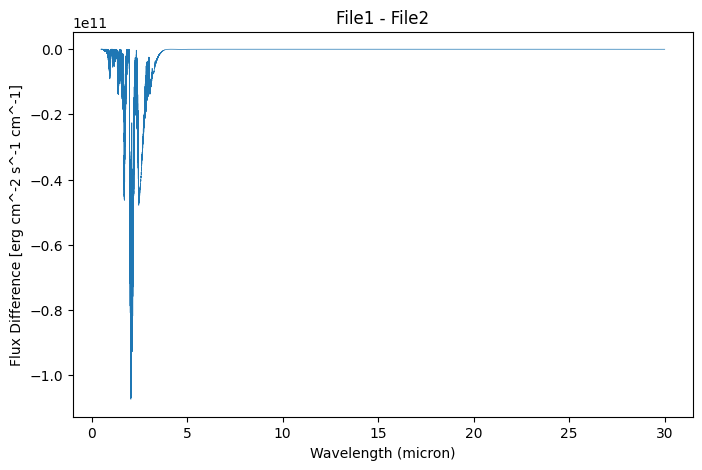

In [12]:
##### STATS

print(f"Length: {len(F1), len(F2)}")
print(f"Min/Max F1: {np.min(F1)}, {np.max(F1)}")
print(f"Min/Max F2: {np.min(F2)}, {np.max(F2)}")

# Differences
diff_abs = F1 - F2
diff_rel = diff_abs / F1

print(f"Mean absolute difference: {np.mean(np.abs(diff_abs))}")
print(f"Mean relative difference: {np.mean(np.abs(diff_rel))}")

# Difference spectrum
plt.figure(figsize=(8,5))
plt.plot(wl1, diff_abs, lw=0.5)
plt.xlabel("Wavelength (micron)")
plt.ylabel("Flux Difference [erg cm^-2 s^-1 cm^-1]")
plt.title("File1 - File2")
plt.show()

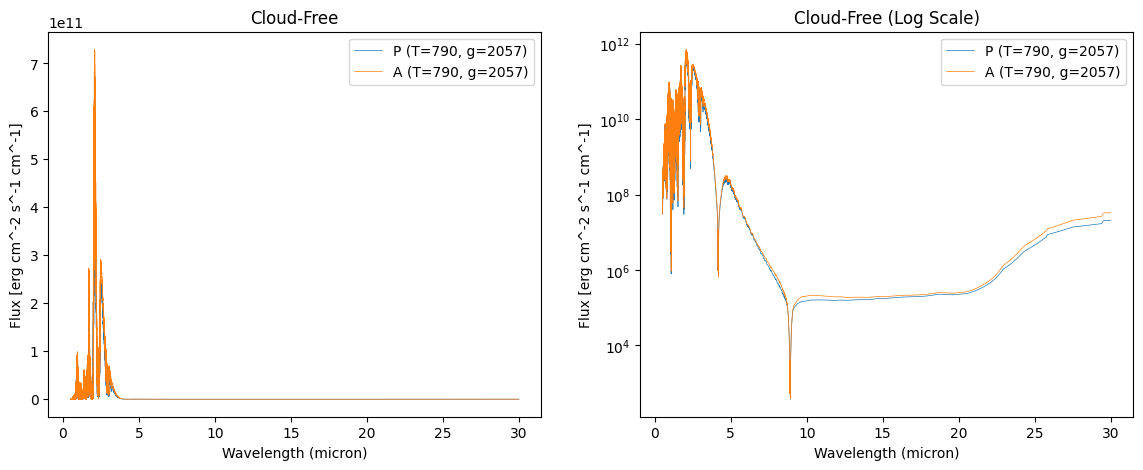

In [13]:
##### CLOUD FREE COMPARE PLOTS

#plt.figure(figsize=(8,5))
#plt.plot(wl1, F1, lw=0.5, label=f"P (T={T1:.0f}, g={g1:.0f})")
#plt.plot(wl2, F2, lw=0.5, label=f"A (T={T2:.0f}, g={g2:.0f})")
#plt.yscale('log')
#plt.xlabel("Wavelength (micron)")
#plt.ylabel("Flux [erg cm^-2 s^-1 cm^-1]")
#plt.title("Cloud-Free")
#plt.legend()
#plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].plot(wl1, F1, lw=0.5, label=f"P (T={T1:.0f}, g={g1:.0f})")
axes[0].plot(wl2, F2, lw=0.5, label=f"A (T={T2:.0f}, g={g2:.0f})")
axes[0].set_xlabel("Wavelength (micron)")
axes[0].set_ylabel("Flux [erg cm^-2 s^-1 cm^-1]")
axes[0].set_title("Cloud-Free")
axes[0].legend()

axes[1].plot(wl1, F1, lw=0.5, label=f"P (T={T1:.0f}, g={g1:.0f})")
axes[1].plot(wl2, F2, lw=0.5, label=f"A (T={T2:.0f}, g={g2:.0f})")
axes[1].set_yscale('log')
axes[1].set_xlabel("Wavelength (micron)")
axes[1].set_ylabel("Flux [erg cm^-2 s^-1 cm^-1]")
axes[1].set_title("Cloud-Free (Log Scale)")
axes[1].legend()

plt.show()

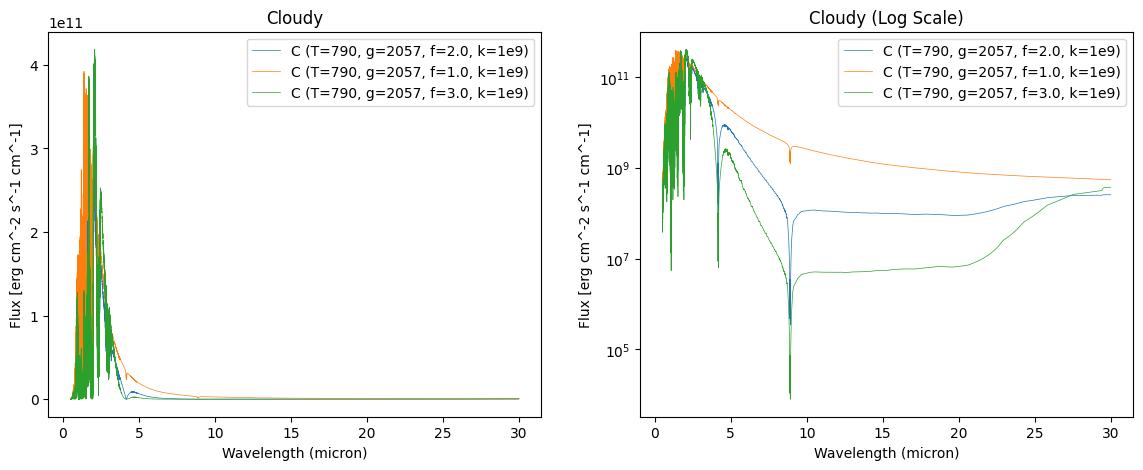

In [14]:
##### CLOUDY PLOT

#plt.figure(figsize=(8,5))
#plt.plot(wlc1, Fc1, lw=0.5, label=f"T={clT1:.0f}, g={cg1:.0f}, f{fsed1:.1f}, k{str(kzz1)}")
#plt.yscale('log')
#plt.xlabel("Wavelength (micron)")
#plt.ylabel("Flux [erg cm^-2 s^-1 cm^-1]")
#plt.title("Cloudy Spectra")
#plt.legend()
#plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].plot(wlc1, Fc1, lw=0.5, label=f"C (T={clT1:.0f}, g={cg1:.0f}, f={fsed1:.1f}, k={str(kzz1)})")
axes[0].plot(wlc2, Fc2, lw=0.5, label=f"C (T={clT2:.0f}, g={cg2:.0f}, f={fsed2:.1f}, k={str(kzz2)})")
axes[0].plot(wlc3, Fc3, lw=0.5, label=f"C (T={clT3:.0f}, g={cg3:.0f}, f={fsed3:.1f}, k={str(kzz3)})")
axes[0].set_xlabel("Wavelength (micron)")
axes[0].set_ylabel("Flux [erg cm^-2 s^-1 cm^-1]")
axes[0].set_title("Cloudy")
axes[0].legend()

axes[1].plot(wlc1, Fc1, lw=0.5, label=f"C (T={clT1:.0f}, g={cg1:.0f}, f={fsed1:.1f}, k={str(kzz1)})")
axes[1].plot(wlc2, Fc2, lw=0.5, label=f"C (T={clT2:.0f}, g={cg2:.0f}, f={fsed2:.1f}, k={str(kzz2)})")
axes[1].plot(wlc3, Fc3, lw=0.5, label=f"C (T={clT3:.0f}, g={cg3:.0f}, f={fsed3:.1f}, k={str(kzz3)})")
axes[1].set_yscale('log')
axes[1].set_xlabel("Wavelength (micron)")
axes[1].set_ylabel("Flux [erg cm^-2 s^-1 cm^-1]")
axes[1].set_title("Cloudy (Log Scale)")
axes[1].legend()

plt.show()

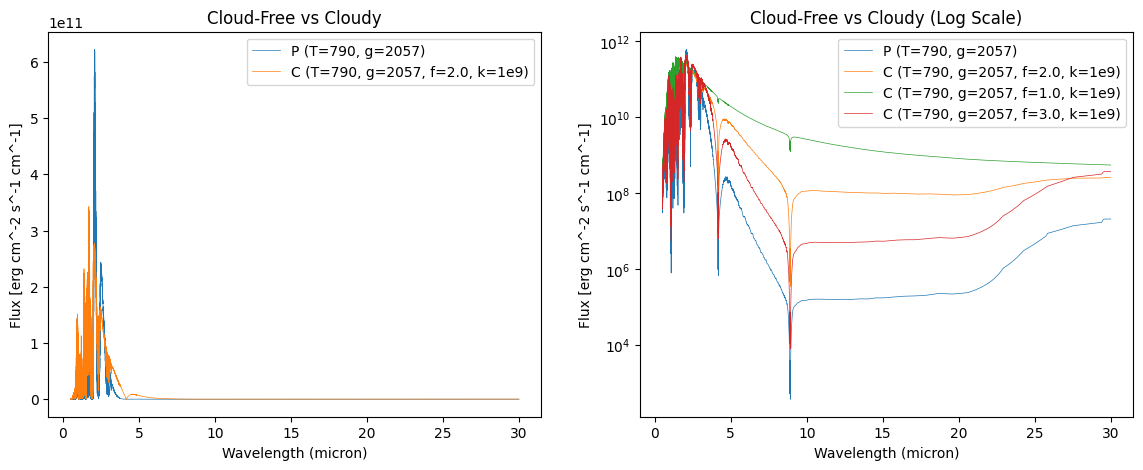

In [15]:
#plt.figure(figsize=(8,5))
#plt.plot(wl1, F1, lw=0.5, label=f"P (T={T1:.0f}, g={g1:.0f})")
#plt.plot(wl2, F2, lw=0.5, label=f"A (T={T2:.0f}, g={g2:.0f})")
#plt.plot(wlc1, Fc1, lw=0.5, label=f"C (T={clT1:.0f}, g={cg1:.0f}, f={fsed1:.1f}, k={str(kzz1)})")
#plt.yscale('log')
#plt.xlabel("Wavelength (micron)")
#plt.ylabel("Flux [erg cm^-2 s^-1 cm^-1]")
#plt.title("Cloudy vs Cloud-Free")
#plt.legend()
#plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
axes[0].plot(wl1, F1, lw=0.5, label=f"P (T={T1:.0f}, g={g1:.0f})")
# axes[0].plot(wl2, F2, lw=0.5, label=f"A (T={T2:.0f}, g={g2:.0f})")
axes[0].plot(wlc1, Fc1, lw=0.5, label=f"C (T={clT1:.0f}, g={cg1:.0f}, f={fsed1:.1f}, k={str(kzz1)})")
axes[0].set_xlabel("Wavelength (micron)")
axes[0].set_ylabel("Flux [erg cm^-2 s^-1 cm^-1]")
axes[0].set_title("Cloud-Free vs Cloudy")
axes[0].legend()

axes[1].plot(wl1, F1, lw=0.5, label=f"P (T={T1:.0f}, g={g1:.0f})")
#axes[1].plot(wl2, F2, lw=0.5, label=f"A (T={T2:.0f}, g={g2:.0f})")
axes[1].plot(wlc1, Fc1, lw=0.5, label=f"C (T={clT1:.0f}, g={cg1:.0f}, f={fsed1:.1f}, k={str(kzz1)})")
axes[1].plot(wlc2, Fc2, lw=0.5, label=f"C (T={clT2:.0f}, g={cg2:.0f}, f={fsed2:.1f}, k={str(kzz2)})")
axes[1].plot(wlc3, Fc3, lw=0.5, label=f"C (T={clT3:.0f}, g={cg3:.0f}, f={fsed3:.1f}, k={str(kzz3)})")
axes[1].set_yscale('log')
axes[1].set_xlabel("Wavelength (micron)")
axes[1].set_ylabel("Flux [erg cm^-2 s^-1 cm^-1]")
axes[1].set_title("Cloud-Free vs Cloudy (Log Scale)")
axes[1].legend()

plt.show()